# Import libraries

In [1]:
import os
from re import search
from dfply import *
import scvelo as scv

In [2]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Load settings

In [3]:
# exec(open('/bi/group/reik/ricard/scripts/gastrulation_multiome_10x/settings.py').read())
# exec(open('/bi/group/reik/ricard/scripts/gastrulation_multiome_10x/utils.py').read())

In [4]:
exec(open('/Users/argelagr/gastrulation_multiome_10x/settings.py').read())
exec(open('/Users/argelagr/gastrulation_multiome_10x/utils.py').read())


## Define I/O

In [5]:
io["anndata_scvelo"] = io["basedir"] + "/results/rna/velocyto/metacells/anndata_scvelo.h5ad"
io["metadata"] = io["basedir"] + "/results/rna/velocyto/metacells/metacells_metadata.txt.gz"
io["outdir"] = io["basedir"] + "/results/rna/velocyto/metacells/pdf"

## Define options 

scanpy options

In [6]:
# %%capture
# sc.settings.verbosity = 3
# sc.logging.print_versions()
sc.settings.set_figure_params(dpi=80, frameon=False, figsize=(8, 7), facecolor='white')

In [7]:
opts["samples"] = [
	"E8.5_CRISPR_T_KO",
	"E8.5_CRISPR_T_WT"
]


opts["celltypes"] = [
  "Caudal_Mesoderm",
  "Somitic_mesoderm",
  "NMP",
  "Spinal_cord"
]

## Load cell metadata

In [13]:
metadata = (pd.read_table(io["metadata"]) >>
    mask(X["sample"].isin(opts["samples"]), X["celltype"].isin(opts["celltypes"]))
)

metadata.shape

(80, 8)

In [14]:
metadata.head(n=3)

,metacell,sample,stage,genotype,celltype,closest.cell,ncells,nFeature_RNA
1288,E8.5_CRISPR_T_KO#AAAGCCCGTGATTTGG-1,E8.5_CRISPR_T_KO,E8.5,T_KO,NMP,cell_30639,23,247222
1307,E8.5_CRISPR_T_KO#ACCAAGCGTACCGGAT-1,E8.5_CRISPR_T_KO,E8.5,T_KO,NMP,cell_136075,34,558333
1316,E8.5_CRISPR_T_KO#ACGTCCAAGGACACTT-1,E8.5_CRISPR_T_KO,E8.5,T_KO,Spinal_cord,cell_37206,51,858016


In [15]:
metadata["sample"].value_counts()

E8.5_CRISPR_T_WT    44
E8.5_CRISPR_T_KO    36
Name: sample, dtype: int64

In [16]:
metadata["celltype"].value_counts()

NMP                 36
Spinal_cord         33
Somitic_mesoderm    11
Name: celltype, dtype: int64

# Load anndata object

In [19]:
exec(open('/Users/argelagr/gastrulation_multiome_10x/utils.py').read())

In [21]:
# adata = sc.read(io["anndata_scvelo"])[metadata.metacell.values,]
adata = load_adata(
    adata_file = io["anndata_scvelo"], 
    cells = metadata.metacell.values, 
    metadata_file = io["metadata"],
    cell_column = "metacell",
    normalise = True, 
    filter_lowly_expressed_genes = False,
    set_colors = True
)
adata

0.00% of cells provided are not observed in the adata, taking the intersect...


AnnData object with n_obs × n_vars = 80 × 2000
    obs: 'metacell', 'sample', 'stage', 'genotype', 'celltype', 'closest.cell', 'ncells', 'nFeature_RNA'
    var: 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'fit_r2', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_steady_u', 'fit_steady_s', 'fit_variance', 'fit_alignment_scaling', 'velocity_genes'
    uns: 'X_name', 'agg_pars', 'celltype_colors', 'n_cells', 'neighbors', 'pca', 'recover_dynamics', 'velocity_params', 'log1p', 'stage_colors'
    obsm: 'X_pca'
    varm: 'PCs', 'loss'
    layers: 'Ms', 'Mu', 'fit_t', 'fit_tau', 'fit_tau_', 'spliced', 'unspliced', 'velocity', 'velocity_u'
    obsp: 'connectivities', 'distances'

In [22]:
adata.obs.head()

,metacell,sample,stage,genotype,celltype,closest.cell,ncells,nFeature_RNA
metacell,,,,,,,,
E8.5_CRISPR_T_KO#AAAGCCCGTGATTTGG-1,E8.5_CRISPR_T_KO#AAAGCCCGTGATTTGG-1,E8.5_CRISPR_T_KO,E8.5,T_KO,NMP,cell_30639,23,247222
E8.5_CRISPR_T_KO#ACCAAGCGTACCGGAT-1,E8.5_CRISPR_T_KO#ACCAAGCGTACCGGAT-1,E8.5_CRISPR_T_KO,E8.5,T_KO,NMP,cell_136075,34,558333
E8.5_CRISPR_T_KO#ACGTCCAAGGACACTT-1,E8.5_CRISPR_T_KO#ACGTCCAAGGACACTT-1,E8.5_CRISPR_T_KO,E8.5,T_KO,Spinal_cord,cell_37206,51,858016
E8.5_CRISPR_T_KO#AGGAACCAGGTCCGTA-1,E8.5_CRISPR_T_KO#AGGAACCAGGTCCGTA-1,E8.5_CRISPR_T_KO,E8.5,T_KO,Spinal_cord,cell_136587,34,327018
E8.5_CRISPR_T_KO#AGGTTAACAGTTATCG-1,E8.5_CRISPR_T_KO#AGGTTAACAGTTATCG-1,E8.5_CRISPR_T_KO,E8.5,T_KO,Spinal_cord,cell_133819,27,392049


## Feature selection

In [29]:
# sc.pp.highly_variable_genes(adata, layer=None, n_top_genes=2500)

# Dimensionality reduction

## PCA

Run PCA

In [30]:
# sc.tl.pca(adata, n_comps=25, svd_solver='arpack')

Plot PCA

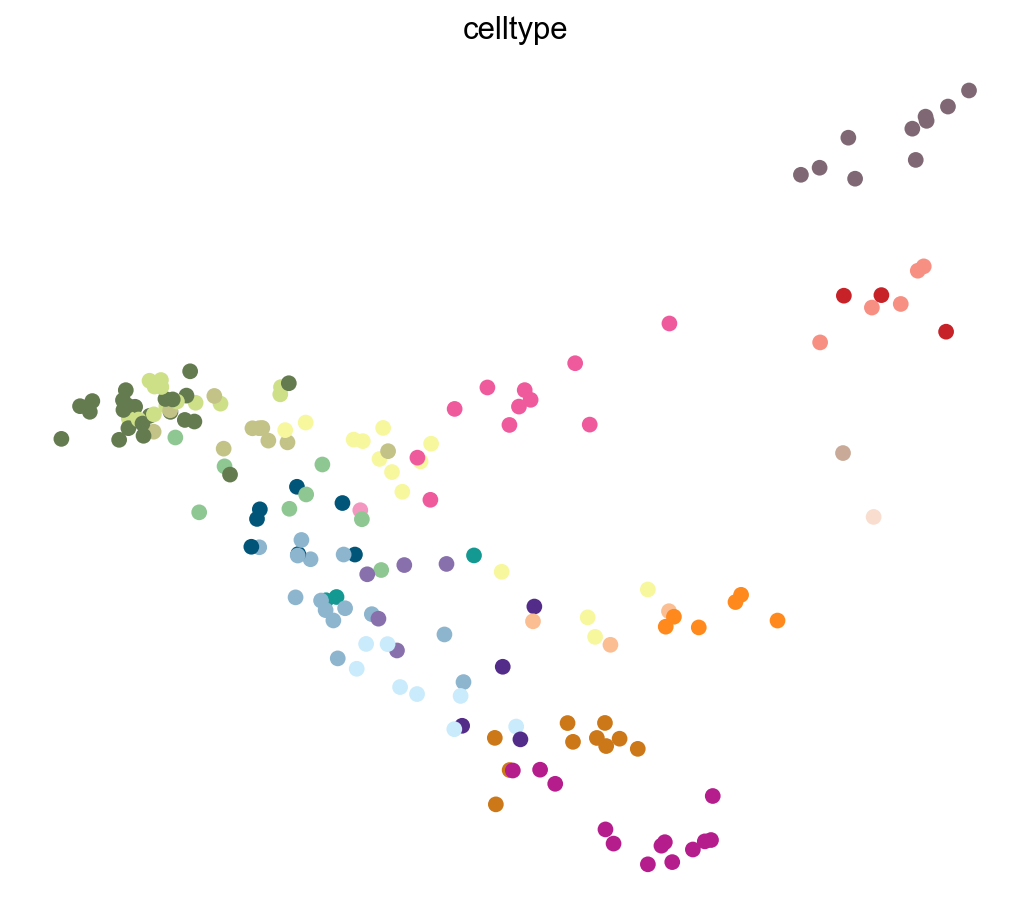

In [33]:
# sc.pl.pca(adata, components=[1,2], color=["celltype"], size=200, legend_loc=None)

## Batch effect correction

In [69]:
# sc.external.pp.harmony_integrate(adata, "stage", basis='X_pca', adjusted_basis='X_pca_harmony')

## k-NN graph

Build kNN graph

In [26]:
sc.pp.neighbors(adata, n_neighbors=5, n_pcs=25)

### Force-directed layout

In [27]:
sc.tl.draw_graph(adata, layout='fa', init_pos=None)

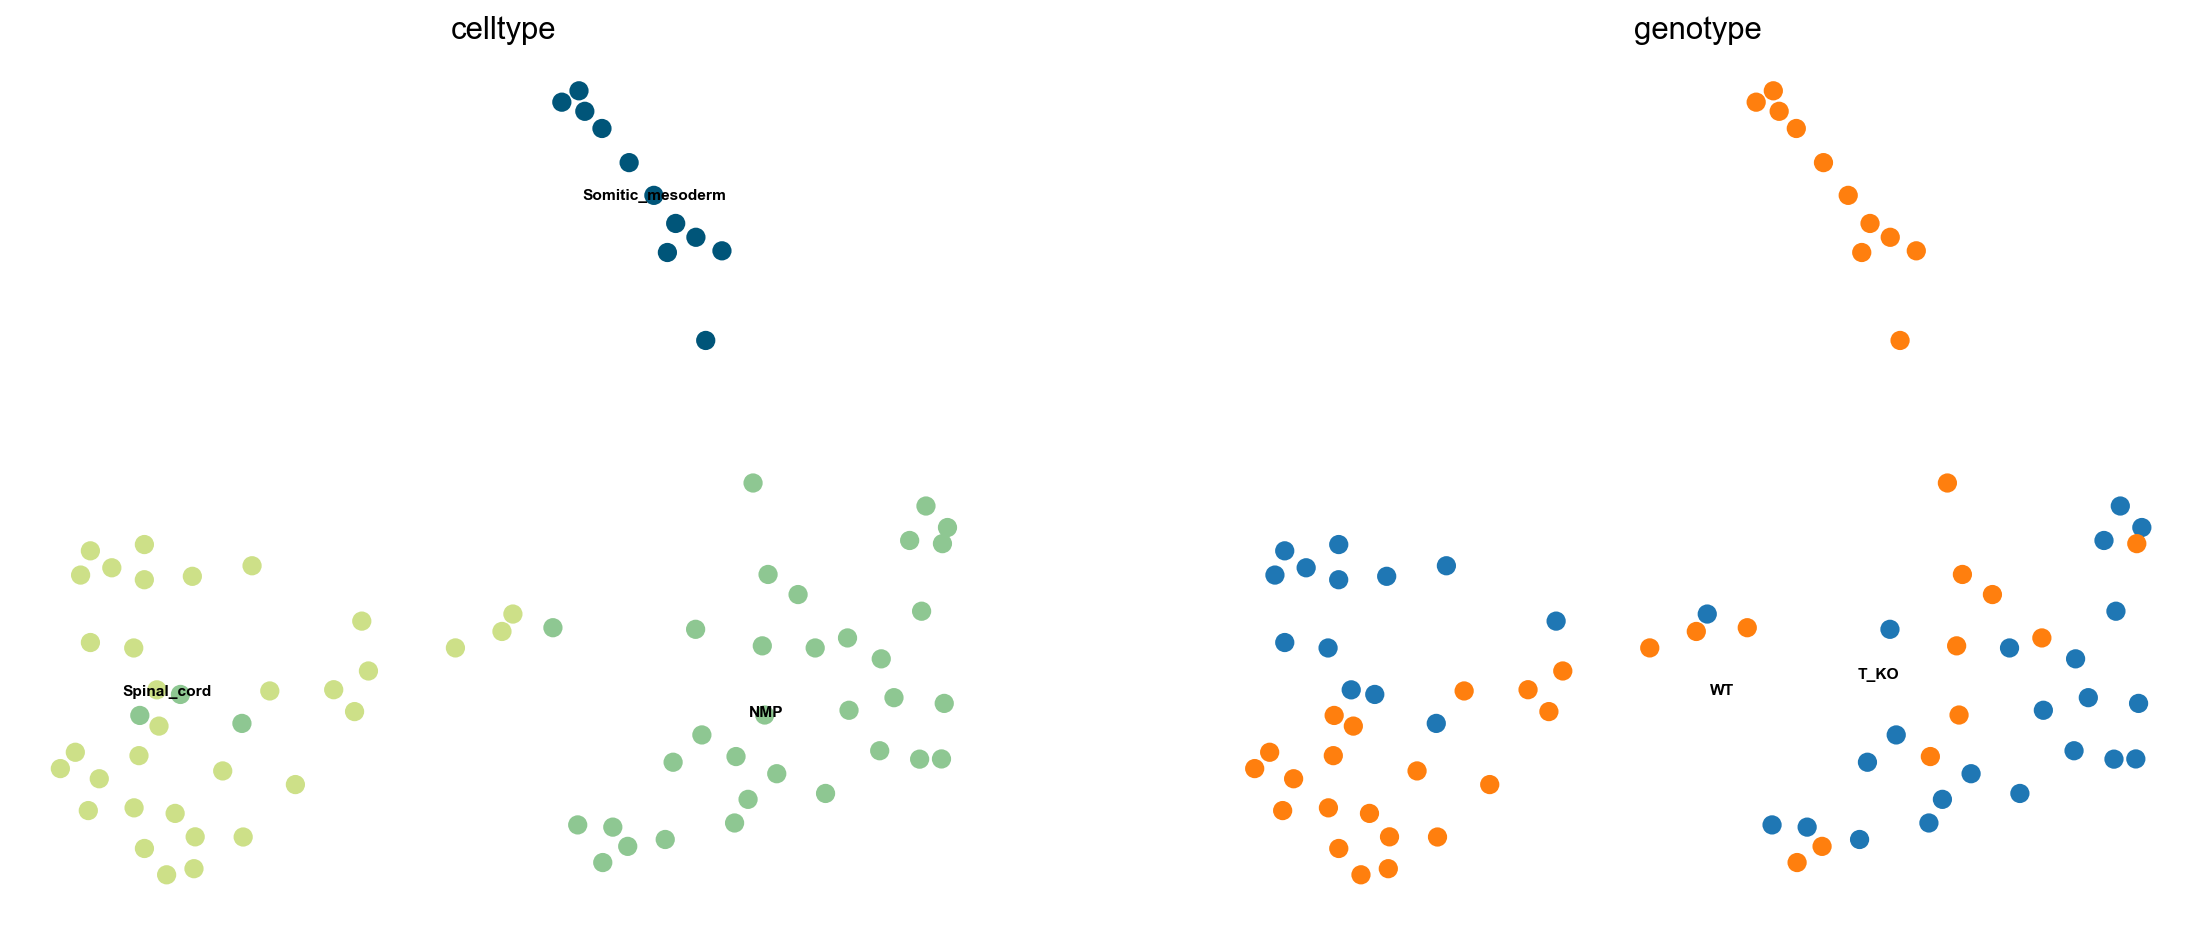

In [28]:
# sc.pl.draw_graph(adata, color='celltype', legend_loc='on data')
sc.pl.draw_graph(adata, color=["celltype","genotype"], size=300, legend_loc='on data', legend_fontsize=7)

## UMAP

Run UMAP

In [53]:
# sc.tl.umap(adata, min_dist=0.5, n_components=2)

Plot UMAP

In [45]:
# sc.pl.umap(adata, color=["celltype.mapped","stage"], size=25, legend_loc="on data")
# sc.pl.umap(adata, color=["celltype.mapped","genotype"], size=50, legend_loc=None)

## Downstream velocity analysis

Computes velocity graph based on cosine similarities.

In [42]:
#scv.tl.velocity_graph(adata)
scv.tl.velocity_graph(adata, approx=True) 

computing velocity graph
    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


scvelo.pl.velocity_embedding_grid(adata, basis=None, vkey='velocity', density=None, smooth=None, min_mass=None, arrow_size=None, arrow_length=None, arrow_color=None, scale=None, autoscale=True, n_neighbors=None, recompute=None, X=None, V=None, X_grid=None, V_grid=None, principal_curve=False, color=None, use_raw=None, layer=None, color_map=None, colorbar=True, palette=None, size=None, alpha=0.2, perc=None, sort_order=True, groups=None, components=None, projection='2d', legend_loc='none', legend_fontsize=None, legend_fontweight=None, xlabel=None, ylabel=None, title=None, fontsize=None, figsize=None, dpi=None, frameon=None, show=None, save=None, ax=None, ncols=None, **kwargs)

In [44]:
# scv.pl.velocity_embedding(adata, basis='umap', color='celltype.mapped', arrow_length=10, arrow_size=10, dpi=120)
scv.pl.velocity_embedding_grid(adata, basis='X_draw_graph_fa', color=['celltype'], arrow_length=5, arrow_size=2, dpi=500, legend_loc="right margin")

scvelo.pl.velocity_embedding_stream(adata, basis=None, vkey='velocity', density=None, smooth=None, min_mass=None, cutoff_perc=None, arrow_color=None, linewidth=None, n_neighbors=None, recompute=None, color=None, use_raw=None, layer=None, color_map=None, colorbar=True, palette=None, size=None, alpha=0.3, perc=None, X=None, V=None, X_grid=None, V_grid=None, sort_order=True, groups=None, components=None, legend_loc='on data', legend_fontsize=None, legend_fontweight=None, xlabel=None, ylabel=None, title=None, fontsize=None, figsize=None, dpi=None, frameon=None, show=None, save=None, ax=None, ncols=None, **kwargs)

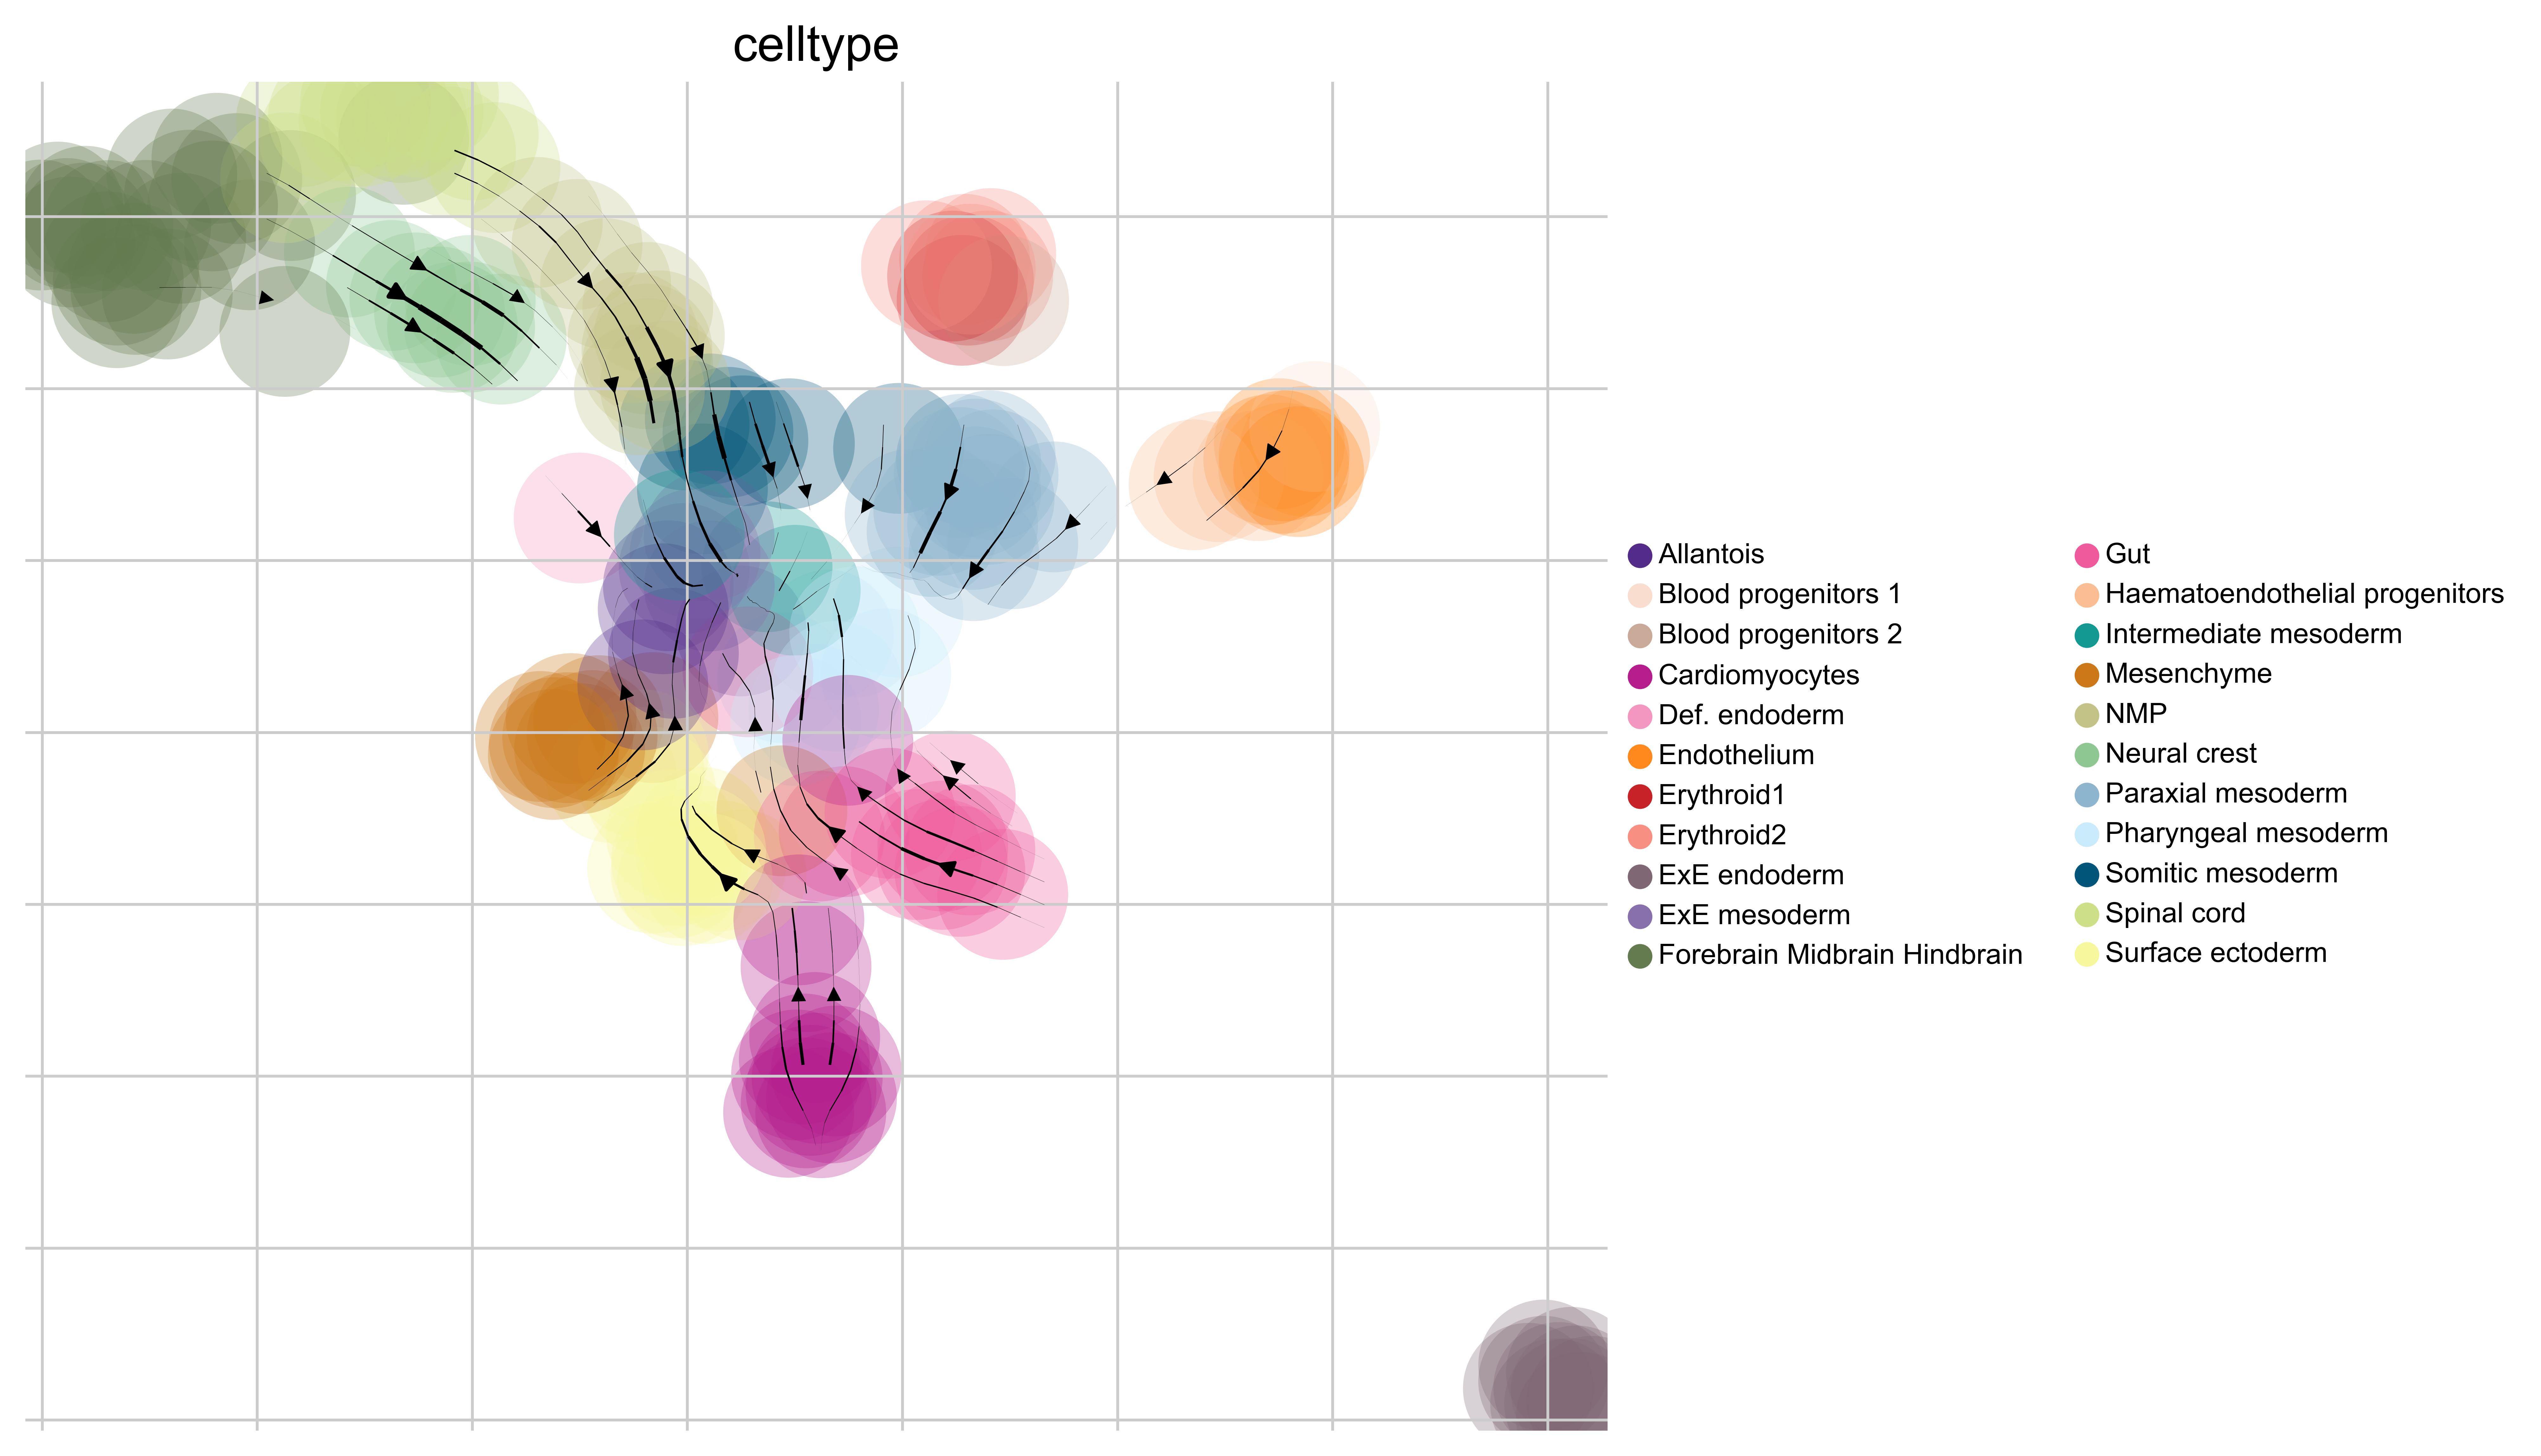

In [48]:
scv.pl.velocity_embedding_stream(adata, basis='X_draw_graph_fa', color=['celltype'], 
    legend_loc='right margin', linewidth=1, legend_fontsize=8, dpi=400)

## Phase portraits 

Now, let us examine the phase portraits of some marker genes, visualized with scv.pl.velocity(adata, gene_names) or scv.pl.scatter(adata, gene_names).

The black line corresponds to the estimated ‘steady-state’ ratio, i.e. the ratio of unspliced to spliced mRNA abundance which is in a constant transcriptional state. RNA velocity for a particular gene is determined as the residual, i.e. how much an observation deviates from that steady-state line. Positive velocity indicates that a gene is up-regulated, which occurs for cells that show higher abundance of unspliced mRNA for that gene than expected in steady state. Conversely, negative velocity indicates that a gene is down-regulated.

In [52]:
# all_genes = adata.var.index
#genes_to_plot = all_genes[all_genes.str.match("^Hb-*")][0]
genes_to_plot = "T"

scvelo.pl.velocity(adata, var_names=None, basis=None, vkey='velocity', mode=None, fits=None, layers='all', color=None, color_map=None, colorbar=True, perc=[2, 98], alpha=0.5, size=None, groupby=None, groups=None, legend_loc='none', legend_fontsize=8, use_raw=False, fontsize=None, figsize=None, dpi=None, show=None, save=None, ax=None, ncols=None, **kwargs)

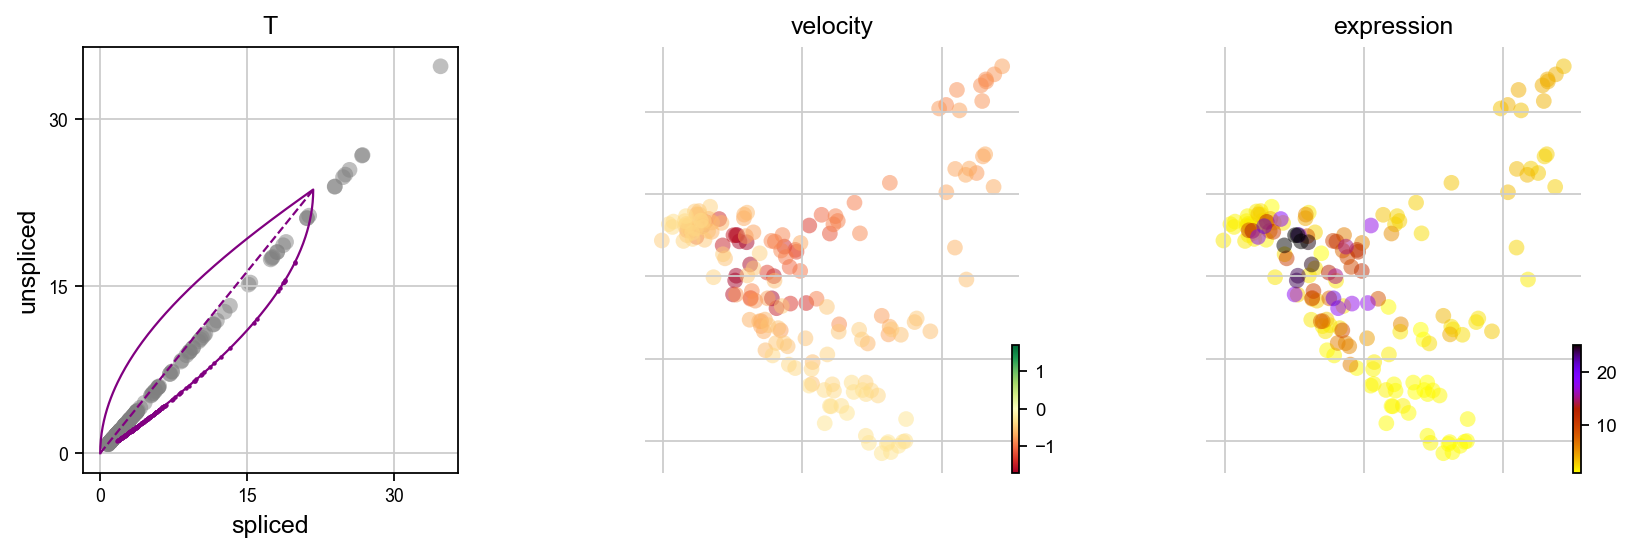

In [55]:
scv.pl.velocity(adata, genes_to_plot, size=200)

scvelo.pl.scatter(adata=None, basis=None, x=None, y=None, vkey=None, color=None, use_raw=None, layer=None, color_map=None, colorbar=None, palette=None, size=None, alpha=None, linewidth=None, linecolor=None, perc=None, groups=None, sort_order=True, components=None, projection=None, legend_loc=None, legend_loc_lines=None, legend_fontsize=None, legend_fontweight=None, legend_fontoutline=None, xlabel=None, ylabel=None, title=None, fontsize=None, figsize=None, xlim=None, ylim=None, add_density=None, add_assignments=None, add_linfit=None, add_polyfit=None, add_rug=None, add_text=None, add_text_pos=None, add_outline=None, outline_width=None, outline_color=None, n_convolve=None, smooth=None, rescale_color=None, color_gradients=None, dpi=None, frameon=None, zorder=None, ncols=None, nrows=None, wspace=None, hspace=None, show=None, save=None, ax=None, **kwargs)

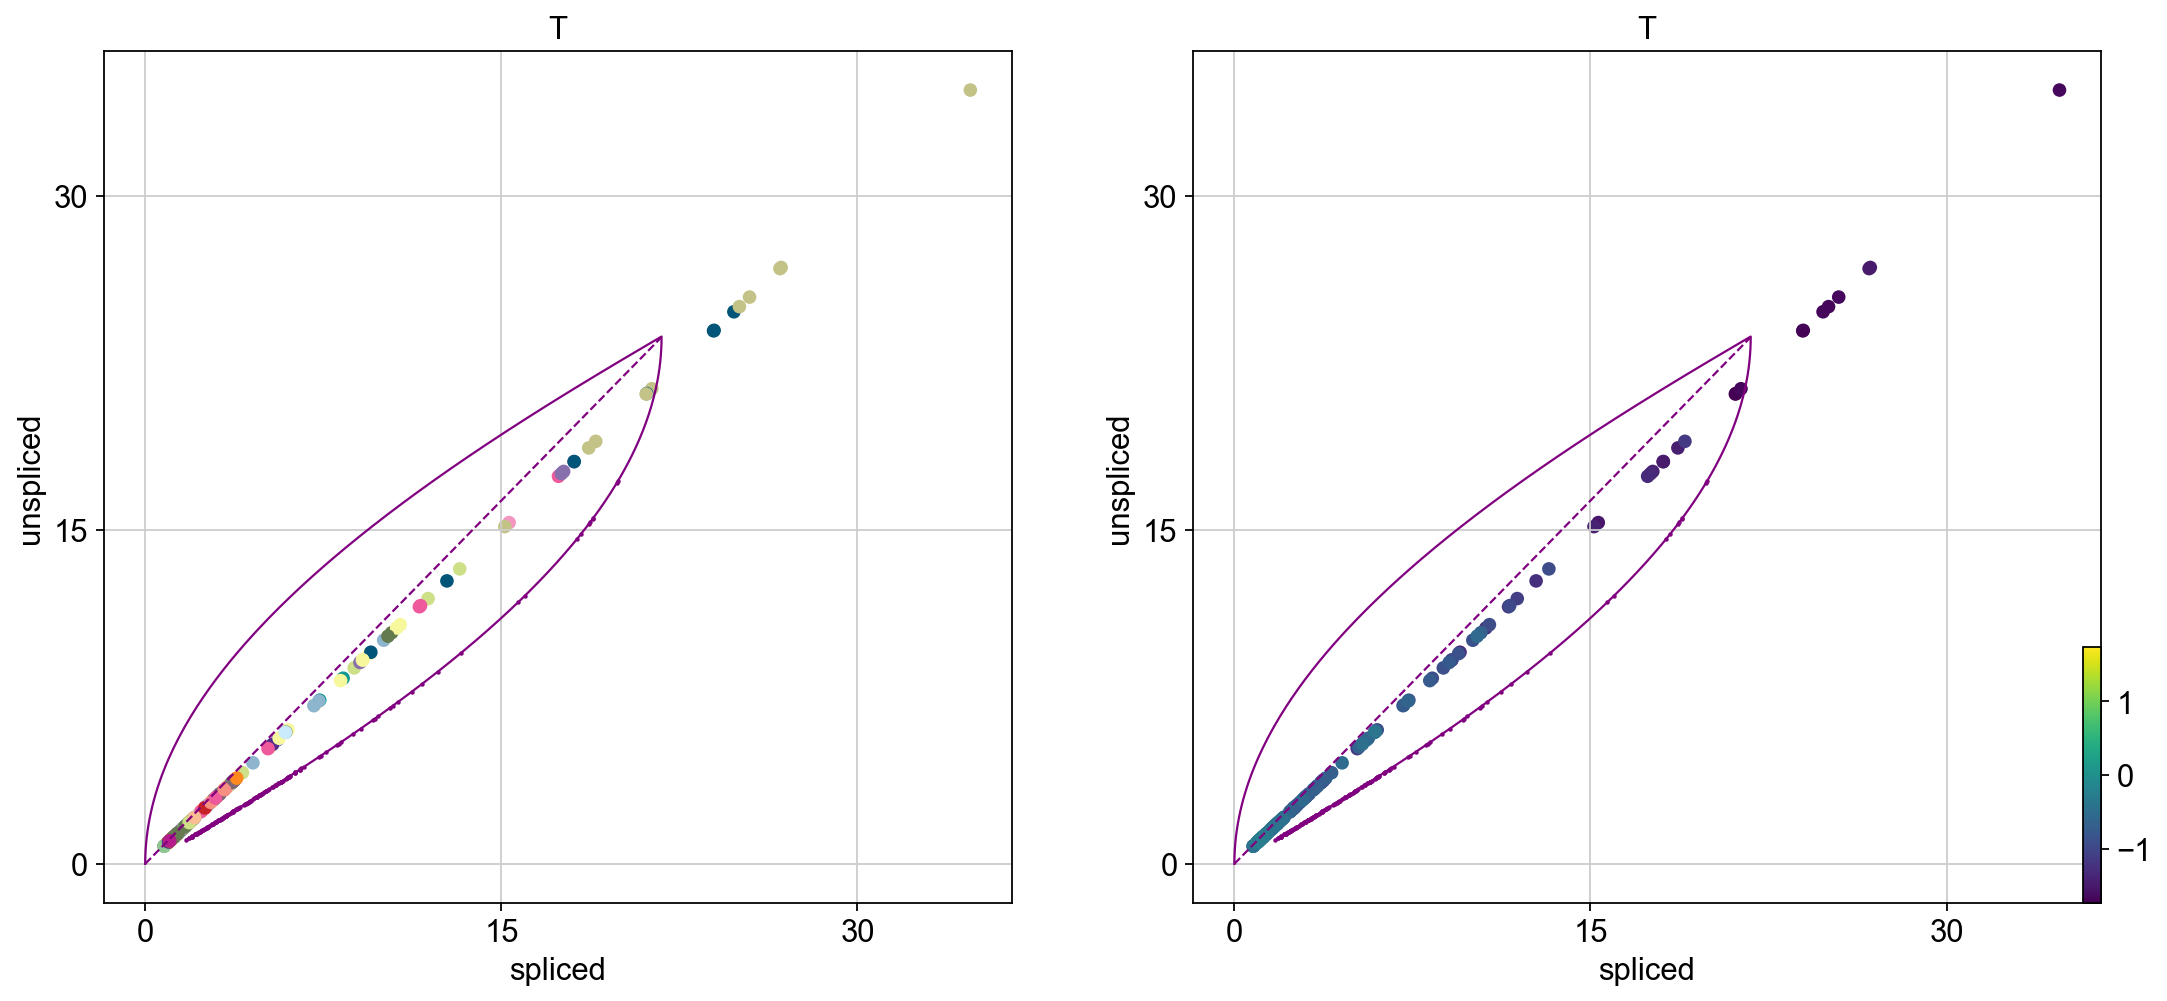

In [57]:
scv.pl.scatter(adata, genes_to_plot, size=150, color=['celltype', 'velocity'])